## General imports

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2, QiskitRuntimeService
from qiskit.visualization import plot_histogram,plot_distribution
import matplotlib.pyplot as plt
import numpy as np

from typing import Optional, List, Dict, Any, Sequence, Tuple

In [2]:
import os, sys

# We are in src/ssp → parent is src, which contains the "ssp" package
PARENT_OF_PACKAGE = os.path.abspath("..")
if PARENT_OF_PACKAGE not in sys.path:
    sys.path.insert(0, PARENT_OF_PACKAGE)

from ssp import SubsetSumInstance
from ssp.solvers import DGSSPSolver, DGConfig, DPSSPSolver, DPConfig
from ssp.backends import (
    BackendSelectionConfig,
    build_service,
    list_real_backends,
    build_all_backends,
    evaluate_backends_for_circuit,
    select_best_backends,
)
from ssp.transpilation import find_best_seed 
from ssp.mitigation import ZNESamplingConfig, dgssp_zne_mitigated_distribution
from ssp.mitigation.zne import _run_folded_circuit_sampling

from ssp.execution import (
    execute_ideal,
    execute_noisy,
    execute_optimized_mitigated,
)

## solvers example

In [3]:
# --- SubsetSum Instance --- 

# Define a small SSP instance
instance = SubsetSumInstance(items=[1,2,3], target=6, name="toy")
seed=42

In [4]:
# --- Classical DP solver test ---

# Create the DP solver (dynamic programming)
dp_cfg = DPConfig(enumerate_all=True)
dp_solver = DPSSPSolver(dp_cfg)

dp_result = dp_solver.solve(instance)

print("Instance:", instance)
print("Number of items:", instance.n_items)
print("Target:", instance.target)

print("\nDP success:", dp_result.success)
print("Optimal value:", dp_result.optimal_value)
print("Best solution:", dp_result.best_solution)

print("\nAll solutions:")
for sol in dp_result.all_solutions:
    print("  indices =", sol.indices,
          "subset =", sol.subset,
          "total =", sol.total,
          "is_exact =", sol.is_exact)


Instance: SubsetSumInstance(items=[1, 2, 3], target=6, name='toy', metadata={})
Number of items: 3
Target: 6

DP success: True
Optimal value: 6
Best solution: SSPSolution(indices=[0, 1, 2], subset=[1, 2, 3], total=6, is_exact=True)

All solutions:
  indices = [0, 1, 2] subset = [1, 2, 3] total = 6 is_exact = True


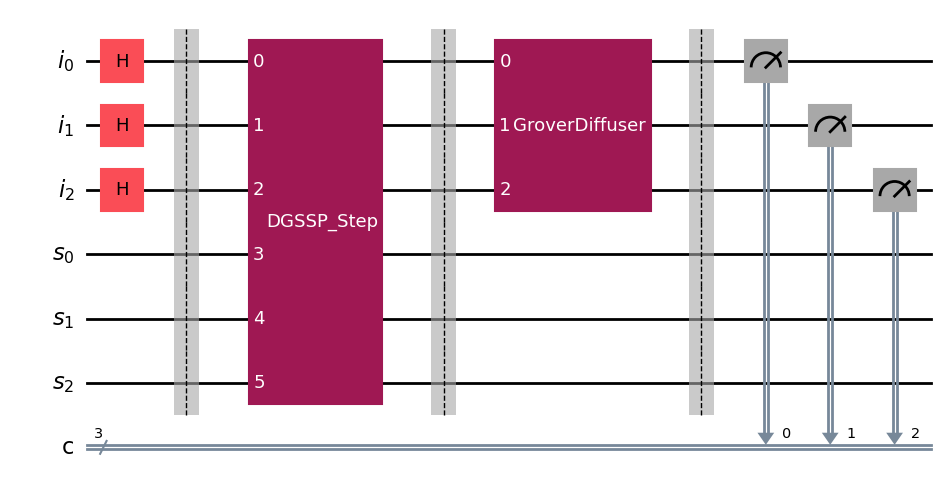

In [5]:
# --- DG circuit construction ---

dg_cfg = DGConfig(assembly_type="FullQFT", iterations=1)
dg_solver = DGSSPSolver(dg_cfg)

qc = dg_solver.build_circuit(instance)

display(qc.draw("mpl"))

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Sequence

# ---- Bitstring ↔ subset helpers ---------------------------------------------

def bitstring_to_subset(bitstring: str, items: Sequence[int]) -> list[int]:
    """LSB-first convention: rightmost bit corresponds to items[0]."""
    bits_lsb = list(reversed(bitstring))
    return [items[i] for i, b in enumerate(bits_lsb) if b == "1"]


def subset_to_str(subset: Sequence[int]) -> str:
    """Pretty string for a subset; empty set as '∅'."""
    return "∅" if len(subset) == 0 else "{" + ", ".join(str(x) for x in subset) + "}"


def bit_is_solution(bitstring: str, items: Sequence[int], target: int) -> bool:
    """True iff the encoded subset of items sums to target."""
    return sum(bitstring_to_subset(bitstring, items)) == target


def make_solution_indicator(items: Sequence[int], target: int):
    """Return F(bit) = 1 if bit encodes a valid SSP solution, else 0."""
    def F(bitstring: str) -> float:
        return 1.0 if bit_is_solution(bitstring, items, target) else 0.0
    return F


# ---- Common preparation for distribution plots ------------------------------

def prepare_distributions_for_plot(
    distributions: Dict[str, Dict[str, float]],
    items: Sequence[int],
    target: int,
):
    """Unify bitstrings across distributions and build arrays and labels.

    Returns
    -------
    all_bits : list[str]
        Sorted list of all bitstrings seen in any distribution.
    x        : np.ndarray
        Positions 0, 1, ..., len(all_bits)-1 for plotting on x-axis.
    ys       : dict[str, np.ndarray]
        Mapping name -> probabilities aligned with all_bits.
    labels   : list[str]
        Pretty subset labels corresponding to all_bits.
    subsets  : list[list[int]]
        Subset (as actual ints) for each bitstring.
    solution_mask : np.ndarray[bool]
        True if subset is a solution, False otherwise.
    """
    # Union of all bitstrings across all distributions
    all_bits = sorted({b for dist in distributions.values() for b in dist.keys()})
    subsets = [bitstring_to_subset(b, items) for b in all_bits]
    labels = [subset_to_str(s) for s in subsets]
    x = np.arange(len(all_bits))

    ys = {
        name: np.array([dist.get(b, 0.0) for b in all_bits])
        for name, dist in distributions.items()
    }

    solution_mask = np.array([sum(sub) == target for sub in subsets])
    return all_bits, x, ys, labels, subsets, solution_mask


# Backends

## Load backends

In [7]:
# Configure where your IBM account JSON is and a min qubit threshold if you want
cfg = BackendSelectionConfig(
    min_qubits=qc.num_qubits,
    seed_simulator=seed,
    real=True
)

# Build the IBM Runtime service
service = build_service(cfg)

In [8]:
# Get *usable* real backends: non-simulators, enough qubits, operational, not in maintenance
real_backends = list_real_backends(service, min_qubits=cfg.min_qubits)

print(f"Found {len(real_backends)} usable real backends:\n")

for backend in real_backends:
    status = backend.status()
    name_attr = getattr(backend, "name", None)
    backend_name = name_attr() if callable(name_attr) else (name_attr or str(backend))

    print(
        f"- {backend_name}: "
        f"{status.backend_version}, "
        f"operational={status.operational}, "
        f"pending_jobs={status.pending_jobs}, "
        f"status_msg='{status.status_msg}'"
    )

Found 3 usable real backends:

- ibm_fez: , operational=True, pending_jobs=215, status_msg='active'
- ibm_torino: , operational=True, pending_jobs=0, status_msg='active'
- ibm_marrakesh: , operational=True, pending_jobs=20197, status_msg='active'


In [9]:
bk = build_all_backends(cfg)

real_backends = bk["real_backends"]
fake_backends = bk["fake_backends"]

In [10]:
real_backends

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_torino')>,
 <IBMBackend('ibm_marrakesh')>]

## Best backend

In [11]:
def accumulated_errors(backend: QiskitRuntimeService.backend, circuit: QuantumCircuit) -> list:
    """Compute accumulated gate and readout errors for a given circuit on a specific backend."""

    # Initializing quantities
    acc_single_qubit_error = 0
    acc_two_qubit_error = 0
    single_qubit_gate_count = 0
    two_qubit_gate_count = 0
    acc_readout_error = 0

    # Defining useful variables
    properties = backend.properties()
    qubit_layout = list(circuit.layout.initial_layout.get_physical_bits().keys())[:qc.num_qubits]

    # ---- TODO : Task 3 ---
    # Goal: Define the following quantities:
    # acc_total_error, acc_two_qubit_error, acc_single_qubit_error, acc_readout_error, single_qubit_gate_count, two_qubit_gate_count

    # TODO Define readout error (only for qubits in qubit_layout) using `properties.readout_error`
    acc_readout_error = 0
    for q in qubit_layout:
        acc_readout_error += properties.readout_error(q)  # TODO
    # TODO Define two qubit gates for the different backends using `backend.configuration()`
    if "ecr" in (backend.configuration().basis_gates):  # TODO
        two_qubit_gate = "ecr"
    elif "cz" in (backend.configuration().basis_gates):  # TODO
        two_qubit_gate = "cz"
    # TODO Loop over the instructions in `circuit.data` to account for the single and two-qubit errors and single and two qubit gate counts
    for instruction in circuit.data:
        if (
            instruction.operation.num_qubits == 1 and instruction.name != "measure"
        ):  # TODO Count and add errors for one qubit gates
            index = instruction.qubits[0]._index
            acc_single_qubit_error += properties.gate_error(gate=instruction.name, qubits=index)
            single_qubit_gate_count += 1
        elif instruction.operation.num_qubits == 2:  # TODO Count and add errors for two qubit gates
            pair = [instruction.qubits[0]._index, instruction.qubits[1]._index]
            acc_two_qubit_error += properties.gate_error(gate=two_qubit_gate, qubits=pair)
            two_qubit_gate_count += 1

    # --- End of TODO ---

    acc_total_error = acc_two_qubit_error + acc_single_qubit_error + acc_readout_error
    results = [
        acc_total_error,
        acc_two_qubit_error,
        acc_single_qubit_error,
        acc_readout_error,
        single_qubit_gate_count,
        two_qubit_gate_count,
    ]
    return results

In [12]:
tqc_list = []
ec_list = []
for noisy_fake_backend in fake_backends:
    pm = generate_preset_pass_manager(
        backend=noisy_fake_backend,
        optimization_level=3,
        seed_transpiler=seed,
    )
    circuit = pm.run(qc)
    tqc_list.append(circuit)

    errors_and_counts = accumulated_errors(noisy_fake_backend, circuit)
    ec_list.append(errors_and_counts)
# You can print your results to visualize if they are correct
for backend, (
    acc_total_error,
    acc_two_qubit_error,
    acc_single_qubit_error,
    acc_readout_error,
    single_qubit_gate_count,
    two_qubit_gate_count,
) in zip(fake_backends, ec_list):
    print(f"Backend {backend.name}")
    print(f"Accumulated two-qubit error of {two_qubit_gate_count} gates: {acc_two_qubit_error:.3f}")
    print(
        f"Accumulated one-qubit error of {single_qubit_gate_count} gates: {acc_single_qubit_error:.3f}"
    )
    print(f"Accumulated readout error: {acc_readout_error:.3f}")
    print(f"Accumulated total error: {acc_total_error:.3f}\n")

Backend aer_simulator_from(ibm_fez)
Accumulated two-qubit error of 109 gates: 0.276
Accumulated one-qubit error of 379 gates: 0.073
Accumulated readout error: 0.050
Accumulated total error: 0.399

Backend aer_simulator_from(ibm_torino)
Accumulated two-qubit error of 113 gates: 0.216
Accumulated one-qubit error of 372 gates: 0.070
Accumulated readout error: 0.167
Accumulated total error: 0.454

Backend aer_simulator_from(ibm_marrakesh)
Accumulated two-qubit error of 109 gates: 0.191
Accumulated one-qubit error of 384 gates: 0.048
Accumulated readout error: 0.120
Accumulated total error: 0.359



# Transpilation

In [13]:
# Best noisy backend: ibm_marrakesh
noisy_backend = fake_backends[0]
real_backend = real_backends[1]

noisy_pm = generate_preset_pass_manager(
    backend=noisy_backend,
    optimization_level=3,
    seed_transpiler=seed,
    layout_method="sabre",
)
noisy_tqc = pm.run(qc)

real_pm = generate_preset_pass_manager(
    backend=real_backend,
    optimization_level=3,
    seed_transpiler=seed,
    layout_method="sabre",
)
real_tqc = pm.run(qc)

In [14]:
def two_qubit_gate_errors_per_circuit_layout(
    circuit: QuantumCircuit, backend: QiskitRuntimeService.backend
) -> tuple:
    """Calculate accumulated two-qubit gate errors and related metrics for a given circuit layout."""
    pair_list = []
    error_pair_list = []
    error_acc_pair_list = []
    two_qubit_gate_count = 0
    properties = backend.properties()
    if "ecr" in (backend.configuration().basis_gates):
        two_qubit_gate = "ecr"
    elif "cz" in (backend.configuration().basis_gates):
        two_qubit_gate = "cz"
    for instruction in circuit.data:
        if instruction.operation.num_qubits == 2:
            two_qubit_gate_count += 1
            pair = [instruction.qubits[0]._index, instruction.qubits[1]._index]
            error_pair = properties.gate_error(gate=two_qubit_gate, qubits=pair)
            if pair not in (pair_list):
                pair_list.append(pair)
                error_pair_list.append(error_pair)
                error_acc_pair_list.append(error_pair)
            else:
                pos = pair_list.index(pair)
                error_acc_pair_list[pos] += error_pair

    acc_two_qubit_error = sum(error_acc_pair_list)
    return (
        acc_two_qubit_error,
        two_qubit_gate_count,
        pair_list,
        error_pair_list,
        error_acc_pair_list,
    )

def finding_best_seed(
    circuit: QuantumCircuit, backend: QiskitRuntimeService.backend
) -> tuple[QuantumCircuit, int, float, int]:
    """Find the transpiler seed that minimizes two-qubit gate error for a given circuit and backend."""

    # We initialize the minimum error accumulated
    min_err_acc_seed_loop = 100
    circuit_opt_best_seed = None
    # First we loop over 500 seeds and transpile the circuit
    for seed_transpiler in range(0, 500):
        pm = generate_preset_pass_manager(
            backend=backend,
            optimization_level=3,
            seed_transpiler=seed_transpiler,
            layout_method="sabre",
        )
        circuit_opt_seed = pm.run([circuit])[0]
        # ---- TODO : Task 5 ---
        # Goal: Find the transpiler seed that minimizes two-qubit gate error for a given circuit and backend looping from 0 to 500

        # TODO Use the `two_qubit_gate_errors_per_circuit_layout` function to count for the error of the transpile circuit
        acc_total_error_seed, two_qubit_gate_count_seed, *_ = (
            two_qubit_gate_errors_per_circuit_layout(circuit_opt_seed, backend)
        )
        # TODO Check if the error accounted above is smaller than min_err_acc_seed_loop. If so, assign the variables that this function returns
        if min_err_acc_seed_loop > acc_total_error_seed:
            min_err_acc_seed_loop = acc_total_error_seed
            circuit_opt_best_seed = circuit_opt_seed
            best_seed_transpiler = seed_transpiler
            two_qubit_gate_count_seed_loop = two_qubit_gate_count_seed
        # --- End of TODO ---

    return (
        circuit_opt_best_seed,
        best_seed_transpiler,
        min_err_acc_seed_loop,
        two_qubit_gate_count_seed_loop,
    )

In [15]:
(
    circuit_opt_seed_loop,
    best_seed_transpiler,
    min_err_acc_seed_loop,
    two_qubit_gate_count_seed_loop,
) = finding_best_seed(qc, noisy_backend)

best_layout = list(circuit_opt_seed_loop.layout.initial_layout.get_physical_bits().keys())[:qc.num_qubits]
print(f"Best noisy transpiler seed: {best_seed_transpiler}")
print(f"Minimum accumulated two-qubit gate error: {min_err_acc_seed_loop:.3f}")
print(f"Two-qubit gate count for best seed: {two_qubit_gate_count_seed_loop}")
print(f"Best layout (first n logical qubits mapped to physical qubits):\n {best_layout}")

Best noisy transpiler seed: 298
Minimum accumulated two-qubit gate error: 0.200
Two-qubit gate count for best seed: 109
Best layout (first n logical qubits mapped to physical qubits):
 [108, 105, 87, 106, 97, 107]


# ZNE

In [16]:
# experiment parameters
shots_backend=2**10
best_seed_transpiler=best_seed_transpiler
best_layout=best_layout

## Qiskit ZNE: Distribution

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

from qiskit import QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

from scipy.optimize import curve_fit

def linear_model(x, a, b):
    return a * x + b


def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c


def exponential_model(x, a, b, c):
    return a * np.exp(-b * x) + c


def zne_method(method="linear", xdata=None, ydata=None):
    if xdata is None or ydata is None:
        raise ValueError("xdata and ydata must be provided.")

    xdata = np.array(xdata, dtype=float)
    ydata = np.array(ydata, dtype=float)

    if method == "linear":
        popt, _ = curve_fit(linear_model, xdata, ydata)
        zero_val = linear_model(0, *popt)
        fit_fn = linear_model
    elif method == "quadratic":
        popt, _ = curve_fit(quadratic_model, xdata, ydata)
        zero_val = quadratic_model(0, *popt)
        fit_fn = quadratic_model
    elif method == "exponential":
        popt, _ = curve_fit(
            exponential_model,
            xdata,
            ydata,
            p0=(1, 0.1, 0),
            maxfev=5000,
        )
        zero_val = exponential_model(0, *popt)
        fit_fn = exponential_model
    else:
        raise ValueError(
            f"Unknown method '{method}'. Use 'linear', 'quadratic', or 'exponential'."
        )

    return float(zero_val), ydata, popt, fit_fn

def plot_zne(scales, values, zero_val, fit_fn, fit_params, method, ylabel="Value"):
    x_plot = np.linspace(0, max(scales), 200)
    y_plot = fit_fn(x_plot, *fit_params)

    plt.figure(figsize=(7, 4))
    plt.plot(scales, values, "o", label="Noisy measurements")
    plt.plot(x_plot, y_plot, "-", label=f"{method.capitalize()} fit")
    plt.axvline(0, linestyle="--", color="gray")
    plt.axhline(zero_val, linestyle="--", color="red", label="Zero-noise estimate")
    plt.xlabel("Noise scaling factor")
    plt.ylabel(ylabel)
    plt.title(f"Zero-Noise Extrapolation ({method})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def fold_local_circuit(circuit: QuantumCircuit, scale_factor: int) -> QuantumCircuit:
    """Perform zero-noise local folding instruction-by-instruction.

    - scale_factor must be an odd positive integer (1, 3, 5, ...).
    - Measurements and barriers are copied but not folded.
    - Qubits / clbits are mapped correctly to the new circuit.
    """
    if scale_factor % 2 == 0 or scale_factor <= 0:
        raise ValueError("scale_factor must be an odd positive integer (1, 3, 5, ...)")

    if scale_factor == 1:
        return circuit

    n_repeat = (scale_factor - 1) // 2

    # Rebuild circuit with same registers
    qc_folded = QuantumCircuit(*circuit.qregs, *circuit.cregs)

    # Map original bits -> new bits
    qubit_map = {old: new for old, new in zip(circuit.qubits, qc_folded.qubits)}
    clbit_map = {old: new for old, new in zip(circuit.clbits, qc_folded.clbits)}

    for instr in circuit.data:
        op = instr.operation
        qargs = [qubit_map[q] for q in instr.qubits]
        cargs = [clbit_map[c] for c in instr.clbits]

        # Do not fold measurement or barrier
        if op.name in ("measure", "barrier"):
            qc_folded.append(op, qargs, cargs)
            continue

        # Original gate
        qc_folded.append(op, qargs, cargs)

        # Local folding: (G · G^†)^n_repeat
        for _ in range(n_repeat):
            qc_folded.append(op, qargs, cargs)
            qc_folded.append(op.inverse(), qargs, cargs)

    return qc_folded

def run_circuit_counts(
    circuit: QuantumCircuit,
    backend,
    shots: int = shots_backend,
    seed_transpiler: int = 0,
    optimization_level: int = 0,
) -> Dict[str, int]:
    """Transpile for backend and return counts."""
    #basis_gates = backend.target.operation_names
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler,
        layout_method= 'sabre'
    )
    tqc = pm.run(circuit)

    result = backend.run(tqc, shots=shots).result()
    return result.get_counts()

def zne_mitigated_distribution(
    circuit: QuantumCircuit,
    backend,
    scales: List[int],
    *,
    shots_per_scale: int = shots_backend,
    seed_transpiler: int = 0,
    optimization_level: int = 3,
    method: str = "linear",
    clip: bool = True,
    renormalize: bool = True,
) -> Dict[str, float]:
    """Compute a ZNE-mitigated probability distribution for a sampling circuit.

    For each scale s in `scales`:
      - fold the circuit locally,
      - transpile and execute on backend,
      - record counts.

    For each bitstring b in the union of supports:
      - build ydata_b = [p_s(b)]_s,
      - apply zne_method(method, scales, ydata_b) to get p_0(b),
      - (optionally) clip and renormalize.

    Returns a dict bitstring -> mitigated probability.
    """

    # 1) Collect counts for each scale
    scale_counts: Dict[int, Dict[str, int]] = {}
    all_bits: set[str] = set()

    for s in scales:
        folded = fold_local_circuit(circuit, s)
        counts_s = run_circuit_counts(
            folded,
            backend=backend,
            shots=shots_per_scale,
            seed_transpiler=seed_transpiler,
            optimization_level=optimization_level,
        )
        scale_counts[s] = counts_s
        all_bits.update(counts_s.keys())

    # 2) For each bitstring, perform scalar ZNE on its probability
    mitigated_probs: Dict[str, float] = {}
    xdata = np.array(scales, dtype=float)

    for bit in sorted(all_bits):
        ydata = []
        for s in scales:
            counts_s = scale_counts[s]
            total_s = sum(counts_s.values())
            p_s = counts_s.get(bit, 0) / total_s if total_s > 0 else 0.0
            ydata.append(p_s)

        # If all zero, skip fitting
        if all(val == 0.0 for val in ydata):
            mitigated_probs[bit] = 0.0
            continue

        zero_val, _, _, _ = zne_method(
            method=method,
            xdata=xdata,
            ydata=ydata,
        )
        mitigated_probs[bit] = float(zero_val)

    # 3) Optional: clip & renormalize
    if clip:
        for k, v in mitigated_probs.items():
            mitigated_probs[k] = max(0.0, min(1.0, v))

    if renormalize:
        Z = sum(mitigated_probs.values())
        if Z > 0:
            for k in mitigated_probs:
                mitigated_probs[k] /= Z

    return mitigated_probs


In [18]:
# Define noise scaling factors (odd integers for local folding)
scales = [1, 3, 5, 7]
method_str='exponential'

#Ideal distribution
ideal_backend=AerSimulator()
ideal_counts = run_circuit_counts(qc, ideal_backend, shots=shots_backend, optimization_level = 0, seed_transpiler=best_seed_transpiler)
p_ideal = {b: c / shots_backend for b, c in ideal_counts.items()}
# Noisy baseline distribution
noisy_counts = run_circuit_counts(qc, noisy_backend, shots=shots_backend, optimization_level = 0, seed_transpiler=best_seed_transpiler)
p_noisy = {b: c / shots_backend for b, c in noisy_counts.items()}

# ZNE-mitigated distribution
p_zne = zne_mitigated_distribution(
    qc,
    noisy_backend,
    scales=scales,
    shots_per_scale=shots_backend,
    seed_transpiler=best_seed_transpiler,
    method=method_str,
    clip=True,
    renormalize=True,
)

In [19]:
solutions = [b for b in p_zne.keys() if bit_is_solution(b, instance.items, instance.target)]
p_sol_noisy = sum(p_noisy.get(b, 0.0) for b in solutions)
p_sol_zne   = sum(p_zne.get(b, 0.0)   for b in solutions)

print("Total P(solution) noisy:", p_sol_noisy)
print("Total P(solution) ZNE  :", p_sol_zne)


Total P(solution) noisy: 0.4892578125
Total P(solution) ZNE  : 0.7155093867138096


In [20]:
def plot_case_subplots(p_ideal, p_noisy, p_zne, instance):
    """Three horizontal subplots: ideal / noisy / ZNE-mitigated."""
    distributions = {
        "Ideal":         p_ideal,
        "Noisy":         p_noisy,
        "ZNE-mitigated": p_zne,
    }

    all_bits, x, ys, labels, subsets, solution_mask = prepare_distributions_for_plot(
        distributions, instance.items, instance.target
    )

    # Collect solution subsets as pretty strings
    solution_labels = [
        subset_to_str(sub)
        for sub, is_sol in zip(subsets, solution_mask) if is_sol
    ]
    solutions_str = ", ".join(solution_labels) if solution_labels else "None"

    # 1 row, 3 columns (side-by-side), share y-axis
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, (name, y) in zip(axes, ys.items()):
        ax.bar(x, y)
        ax.set_title(name)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90)
        ax.set_xlabel("Subset $S \\subseteq A$")
        ax.grid(True, axis="y", linestyle=":", alpha=0.5)

    # Only the first subplot needs the y-label
    axes[0].set_ylabel("P(subset)")

    fig.suptitle(
        f"DG-SSP sampling distributions per case\n"
        f"Instance '{instance.name}': A={instance.items}, "
        f"target={instance.target}\n"
        f"Exact solutions (sum = {instance.target}): {solutions_str}",
        y=1.05,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig


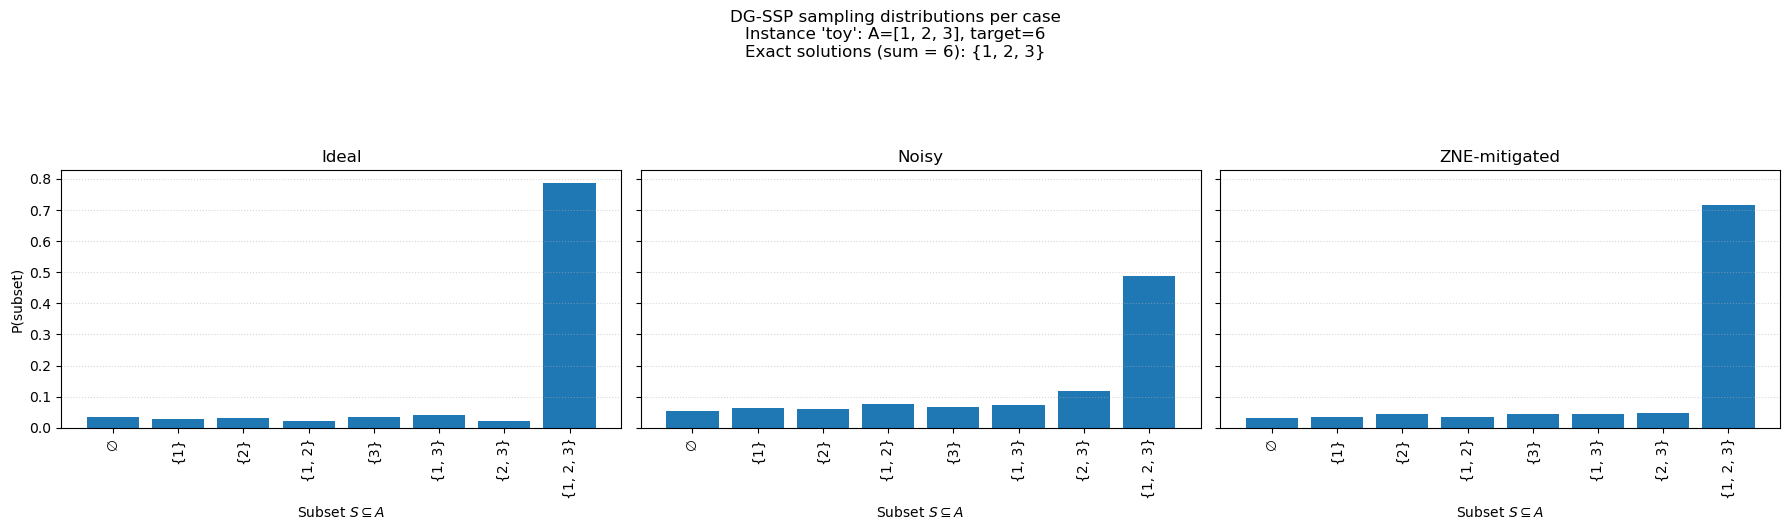

In [21]:
# Call it after p_ideal, p_noisy, p_zne are defined
_ = plot_case_subplots(p_ideal, p_noisy, p_zne, instance)

In [22]:
def plot_overlay_distributions(p_ideal, p_noisy, p_zne, instance):
    """Single plot with grouped bars for ideal / noisy / ZNE-mitigated."""
    distributions = {
        "Ideal":          p_ideal,
        "Noisy":          p_noisy,
        "ZNE-mitigated":  p_zne,
    }

    all_bits, x, ys, labels, subsets, solution_mask = prepare_distributions_for_plot(
        distributions, instance.items, instance.target
    )

    # Solutions as text
    solution_labels = [
        subset_to_str(sub)
        for sub, is_sol in zip(subsets, solution_mask) if is_sol
    ]
    solutions_str = ", ".join(solution_labels) if solution_labels else "None"

    # Total P(solution) for each case (using the same union of bitstrings)
    p_solution = {}
    for name, dist in distributions.items():
        p_solution[name] = sum(
            dist.get(bit, 0.0)
            for bit, is_sol in zip(all_bits, solution_mask)
            if is_sol
        )

    fig, ax = plt.subplots(figsize=(16, 6))

    width = 0.25
    offsets = [-width, 0.0, width]

    for offset, (name, y) in zip(offsets, ys.items()):
        ax.bar(
            x + offset,
            y,
            width=width,
            label=f"{name} (P(sol) ≈ {p_solution[name]:.3f})",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)
    ax.set_ylabel("P(subset)")
    ax.set_xlabel("Subset $S \\subseteq A$")
    ax.set_title(
        "DG-SSP sampling distribution: ideal vs noisy vs ZNE-mitigated\n"
        f"Instance '{instance.name}': A={instance.items}, target={instance.target}\n"
        f"Exact solutions (sum = {instance.target}): {solutions_str}"
    )
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax.legend()
    fig.tight_layout()
    return fig

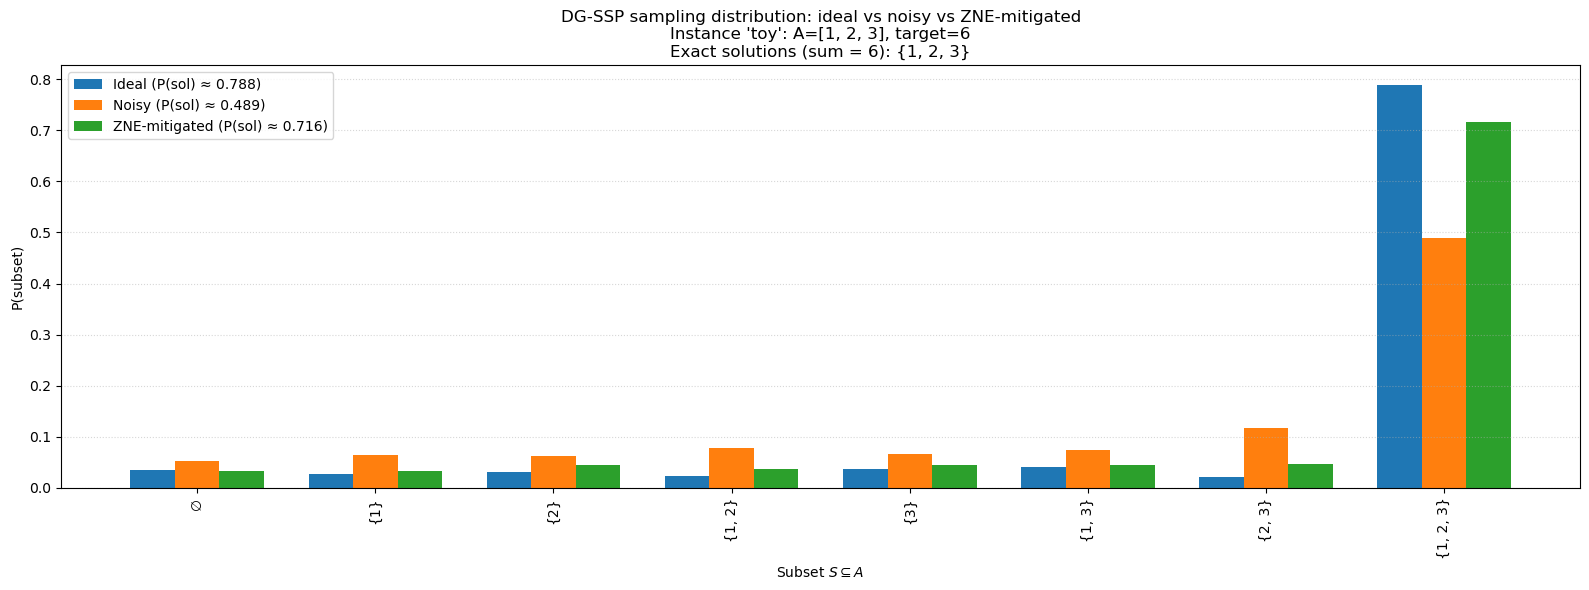

In [23]:
# Call it
_ = plot_overlay_distributions(p_ideal, p_noisy, p_zne, instance)

## Qiskit ZNE: Global ZNE

In [24]:
from typing import Callable, Dict
import numpy as np

def observable_from_counts(
    counts: Dict[str, int],
    F: Callable[[str], float],
) -> float:
    """Estimate E[F(bitstring)] from measurement counts."""
    total = sum(counts.values())
    if total == 0:
        return 0.0
    return sum(F(bit) * c for bit, c in counts.items()) / total

def zne_global_observable(
    circuit: QuantumCircuit,
    backend,
    scales,                          # e.g. [1, 3, 5]
    F: Callable[[str], float],       # global observable on bitstrings
    *,
    shots_per_scale: int = shots_backend,
    seed_transpiler: int = best_seed_transpiler,
    optimization_level: int = 0,
    method: str = "linear",
):
    """Zero-Noise Extrapolation for a global observable E[F(bitstring)].

    Returns
    -------
    zero_val : float
        Extrapolated zero-noise estimate of E[F].
    meta : dict
        Contains raw scales, noisy values per scale, fit params, etc.
    """

    xdata = np.array(scales, dtype=float)
    ydata = []

    # 1) For each scale, fold -> run -> estimate E[F]
    for s in scales:
        folded = fold_local_circuit(circuit, s)
        counts_s = run_circuit_counts(
            folded,
            backend=backend,
            shots=shots_per_scale,
            seed_transpiler=seed_transpiler,
            optimization_level=optimization_level,
        )
        E_s = observable_from_counts(counts_s, F)
        ydata.append(E_s)

    # 2) Extrapolate to zero noise
    zero_val, fitted_vals, fit_params, fit_fn = zne_method(
        method=method,
        xdata=xdata,
        ydata=ydata,
    )

    meta = {
        "scales": xdata,
        "values": np.array(ydata),
        "fit_params": fit_params,
        "fit_fn": fit_fn,
    }
    return zero_val, meta


In [25]:
F_sol = make_solution_indicator(instance.items, instance.target)

# Baseline noisy probability of sampling a solution (scale=1)
p_sol_noisy = observable_from_counts(noisy_counts, F_sol)
print("Solution:", F_sol)
print("Noisy P(solution):", p_sol_noisy)

# ZNE-mitigated probability of sampling a solution
p_sol_zne, meta = zne_global_observable(
    qc,
    noisy_backend,
    scales=scales,
    F=F_sol,
    shots_per_scale=shots_backend,
    seed_transpiler=best_seed_transpiler,
    optimization_level=3,
    method=method_str,      # or "quadratic", "exponential"
)

print("ZNE-mitigated P(solution):", p_sol_zne)
print("Per-scale values E[F] :", meta["values"])
print("Scales used          :", meta["scales"])


Solution: <function make_solution_indicator.<locals>.F at 0x000001CD29DB1800>
Noisy P(solution): 0.4892578125
ZNE-mitigated P(solution): 1.3522202780820614
Per-scale values E[F] : [0.61132812 0.20410156 0.20117188 0.11328125]
Scales used          : [1. 3. 5. 7.]


In [26]:
def plot_zne_methods_grid(
    circuit,
    backend,
    scales,
    F,
    shots_per_scale,
    seed_transpiler,
    optimization_level,
    instance,
):
    """One figure, three subplots: linear / quadratic / exponential ZNE fits."""
    methods = ["linear", "quadratic", "exponential"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, method in zip(axes, methods):
        zero_val, meta = zne_global_observable(
            circuit,
            backend,
            scales=scales,
            F=F,
            shots_per_scale=shots_per_scale,
            seed_transpiler=seed_transpiler,
            optimization_level=optimization_level,
            method=method,
        )

        xdata = np.array(meta["scales"], dtype=float)
        ydata = np.array(meta["values"], dtype=float)
        fit_fn = meta["fit_fn"]
        fit_params = meta["fit_params"]

        x_plot = np.linspace(0.0, max(xdata), 200)
        y_plot = fit_fn(x_plot, *fit_params)

        ax.plot(xdata, ydata, "o", label="Noisy measurements")
        ax.plot(x_plot, y_plot, "-", label=f"{method.capitalize()} fit")
        ax.axvline(0.0, linestyle="--", color="gray")
        ax.axhline(
            zero_val,
            linestyle="--",
            color="red",
            label=f"Zero-noise ≈ {zero_val:.3f}",
        )
        ax.set_title(method.capitalize())
        ax.set_xlabel("Noise scaling factor")
        ax.grid(True, linestyle=":", alpha=0.5)

        if ax is axes[0]:
            ax.set_ylabel("E[F(bitstring)]")

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    fig.suptitle(
        "Zero-Noise Extrapolation for global SSP observable\n"
        f"Instance '{instance.name}': A={instance.items}, target={instance.target}",
        y=1.05,
    )
    fig.tight_layout()
    return fig


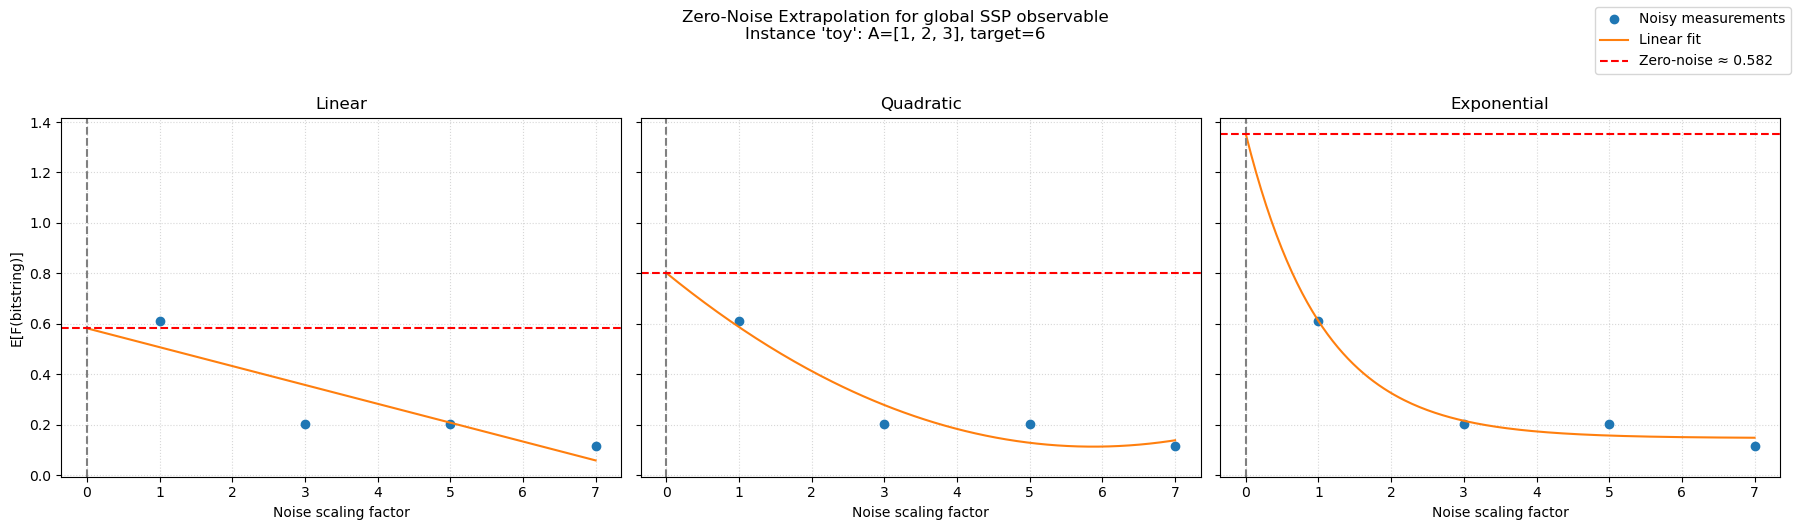

In [27]:
_ = plot_zne_methods_grid(
    qc,
    noisy_backend,
    scales=scales,
    F=F_sol,
    shots_per_scale=shots_backend,
    seed_transpiler=best_seed_transpiler,
    optimization_level=3,
    instance=instance,
)